In [1]:
import os, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_jsonl(filepath):
    with open(filepath, 'r', encoding='utf-8') as file:
        data = [json.loads(line) for line in file if line.strip()]

    return data

def save_jsonl(dataset, filepath):
    with open(filepath, 'w', encoding='utf-8') as file:
        for d in dataset:
            json.dump(d, file, ensure_ascii=False)
            file.write('\n')

In [3]:
run_name = "ch11_train"

checkpoint_dir = Path("data") / "ch11"

In [4]:
#epoches, steps = [], []
#train_losses, val_losses = [], []
#learning_rates, created_at = [], []

#json_files = sorted(
#    checkpoint_dir.glob("checkpoint_*.json"),
#    key=lambda x: x.stat().st_ctime,
#    #key=lambda x: int(x.name.split("-")[1]),
#    reverse=False,
#)

dataset = []
jsonl_file = checkpoint_dir / "checkpoints.jsonl"
json_files = list(checkpoint_dir.glob("checkpoint_*.json"))

if jsonl_file.exists():
    dataset = read_jsonl(jsonl_file)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())
    #tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    #epoch, step = int(tags[0]), int(tags[1])
    dataset.append(data)

dataset = sorted(dataset, key=lambda x: x['step'], reverse=False)

#df = pd.DataFrame.from_records(dataset, columns=columns)
df = pd.DataFrame.from_records(dataset)
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step'], keep='last')

dataset = df.to_dict(orient='records')
dataset = [{k: v for k, v in rec.items() if pd.notna(v)} for rec in dataset]

In [5]:
#df = pd.DataFrame({
#    "epoch": epoches,
#    "step": steps,
#    "train_loss": train_losses,
#    "val_loss": val_losses,
#    "learning_rate": learning_rates,
#    "created_at": created_at,
#})

save_jsonl(dataset, jsonl_file)

for jf in json_files:
    pt = Path(str(jf).replace(".json", ".pt"))
    if not pt.exists():
        os.remove(jf)

steps = df['step'].apply(lambda x: x/1e3).to_list()
df['step'] = df['step'].apply(lambda x: f"{x:_}")

df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

columns=["epoch", "step", "train_loss", "val_loss", "learning_rate", "created_at"]

In [6]:
#pd.concat((df.head(10), df.tail(10)))

df.nsmallest(10, 'train_loss')[columns]

,epoch,step,train_loss,val_loss,learning_rate,created_at
199,10,1_800_000,0.767238,2.914645,0.000500,2025-09-27T20:35:43%:z
197,10,1_790_000,0.768321,2.908395,0.000006,2025-09-27T20:08:54%:z
196,10,1_780_000,0.769728,2.899018,0.000008,2025-09-27T19:42:05%:z
194,10,1_760_000,0.770310,2.913560,0.000017,2025-09-27T18:48:30%:z
195,10,1_770_000,0.770668,2.895591,0.000012,2025-09-27T19:15:18%:z
193,10,1_750_000,0.771404,2.909402,0.000024,2025-09-27T18:21:42%:z
192,10,1_740_000,0.773183,2.909507,0.000032,2025-09-27T17:54:53%:z
191,10,1_730_000,0.774958,2.927866,0.000041,2025-09-27T17:28:04%:z
190,10,1_720_000,0.778850,2.903766,0.000052,2025-09-27T17:01:15%:z
189,10,1_710_000,0.781031,2.888037,0.000064,2025-09-27T16:34:26%:z


In [7]:
df[columns].head(20)

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,10_000,4.176673,4.291854,0.000030,2025-09-24T11:48:37%:z
1,1,20_000,3.308498,3.575430,0.000054,2025-09-24T12:14:59%:z
2,1,30_000,2.705407,3.101106,0.000079,2025-09-24T12:41:19%:z
3,1,40_000,2.383211,2.852906,0.000104,2025-09-24T13:07:40%:z
4,1,50_000,2.186624,2.738719,0.000129,2025-09-24T13:33:59%:z
5,1,60_000,2.044954,2.678819,0.000154,2025-09-24T14:00:20%:z
6,1,70_000,1.909677,2.629908,0.000178,2025-09-24T14:26:39%:z
7,1,80_000,1.831938,2.612191,0.000203,2025-09-24T14:52:59%:z
8,1,90_000,1.750958,2.611796,0.000228,2025-09-24T15:19:18%:z
9,1,100_000,1.675285,2.578590,0.000252,2025-09-24T15:45:37%:z


In [8]:
df[columns].tail(20)

,epoch,step,train_loss,val_loss,learning_rate,created_at
190,10,1_720_000,0.778850,2.903766,0.000052,2025-09-27T17:01:15%:z
191,10,1_730_000,0.774958,2.927866,0.000041,2025-09-27T17:28:04%:z
192,10,1_740_000,0.773183,2.909507,0.000032,2025-09-27T17:54:53%:z
193,10,1_750_000,0.771404,2.909402,0.000024,2025-09-27T18:21:42%:z
194,10,1_760_000,0.770310,2.913560,0.000017,2025-09-27T18:48:30%:z
195,10,1_770_000,0.770668,2.895591,0.000012,2025-09-27T19:15:18%:z
196,10,1_780_000,0.769728,2.899018,0.000008,2025-09-27T19:42:05%:z
197,10,1_790_000,0.768321,2.908395,0.000006,2025-09-27T20:08:54%:z
199,10,1_800_000,0.767238,2.914645,0.000500,2025-09-27T20:35:43%:z
200,10,1_810_000,0.886295,2.692637,0.000499,2025-09-27T21:02:33%:z


In [9]:
df[columns].tail(20)

,epoch,step,train_loss,val_loss,learning_rate,created_at
190,10,1_720_000,0.778850,2.903766,0.000052,2025-09-27T17:01:15%:z
191,10,1_730_000,0.774958,2.927866,0.000041,2025-09-27T17:28:04%:z
192,10,1_740_000,0.773183,2.909507,0.000032,2025-09-27T17:54:53%:z
193,10,1_750_000,0.771404,2.909402,0.000024,2025-09-27T18:21:42%:z
194,10,1_760_000,0.770310,2.913560,0.000017,2025-09-27T18:48:30%:z
195,10,1_770_000,0.770668,2.895591,0.000012,2025-09-27T19:15:18%:z
196,10,1_780_000,0.769728,2.899018,0.000008,2025-09-27T19:42:05%:z
197,10,1_790_000,0.768321,2.908395,0.000006,2025-09-27T20:08:54%:z
199,10,1_800_000,0.767238,2.914645,0.000500,2025-09-27T20:35:43%:z
200,10,1_810_000,0.886295,2.692637,0.000499,2025-09-27T21:02:33%:z


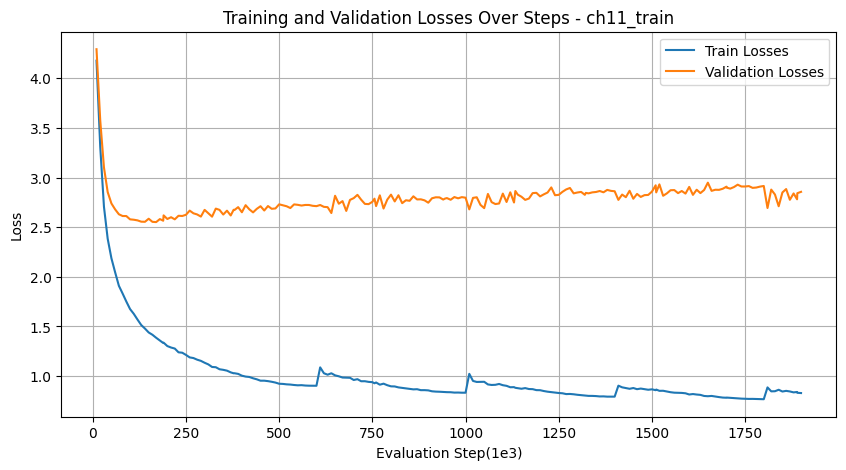

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['train_loss'], label="Train Losses")
plt.plot(steps, df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

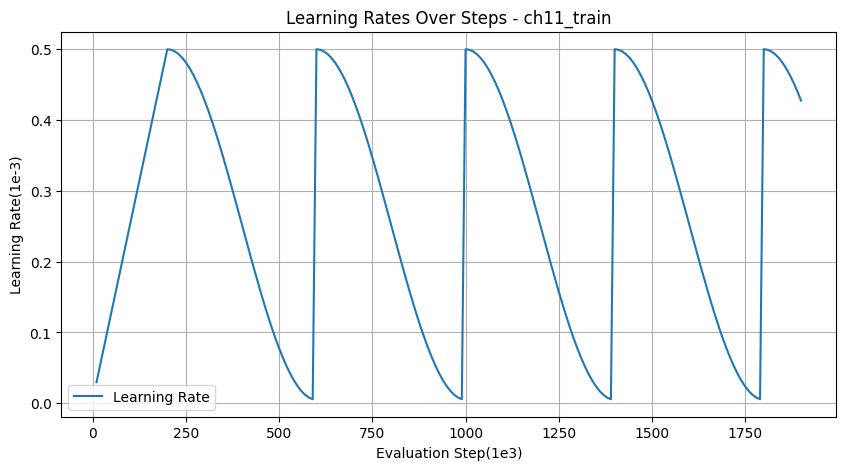

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(steps, df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")